In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [2]:
arabi_genes = pd.read_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/Ortho_vs_gene_files/arabi_gene_results.csv', index_col= 0)
arabi_ortho = pd.read_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/Ortho_vs_gene_files/arabi_ortho_trimmed_out_2_gene_families.csv', index_col= 0)
tomato_genes = pd.read_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/Ortho_vs_gene_files/maize_gene_results.csv', index_col= 0)
tomato_ortho = pd.read_csv('/vault/transfer/passala/Module_paper_data/maize_non_matching_comparison/Ortho_vs_gene_files/maize_ortho_trimmed_out_2_gene_families.csv', index_col= 0)

In [3]:
log_fc_change_evaluation_value = 1.5
log_fc_change_evaluation_value_negative = -1*log_fc_change_evaluation_value

In [4]:
tomato_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
10077at3193,29.545605,-3.303409,0.453894,-7.277930,3.389822e-13,1.872867e-12
10217at3193,94.418807,-0.871986,0.182575,-4.776044,1.787771e-06,5.446464e-06
105017at3193,25.128518,7.740641,1.351160,5.728886,1.010922e-08,3.922346e-08
10648at3193,790.240805,-0.817760,0.258080,-3.168629,1.531595e-03,3.196763e-03
10653at3193,231.999506,3.631205,0.213097,17.040173,4.135083e-65,1.255149e-63
...,...,...,...,...,...,...
97899at3193,123.885689,0.224134,0.203996,1.098720,2.718903e-01,3.451849e-01
9789at3193,259.250773,0.040918,0.138310,0.295841,7.673518e-01,8.149940e-01
9797at3193,65.311180,0.710791,0.212543,3.344229,8.251147e-04,1.795201e-03
9942at3193,932.655747,0.237622,0.086417,2.749720,5.964626e-03,1.119604e-02


In [5]:
trimmed_tomato_ortho = tomato_ortho.loc[tomato_ortho.index.isin(arabi_ortho.index)]
trimmed_arabi_ortho = arabi_ortho.loc[arabi_ortho.index.isin(trimmed_tomato_ortho.index)]


In [6]:
trimmed_arabi_ortho_named = trimmed_arabi_ortho.rename(columns = {'log2FoldChange':'Arabidopsis Log2FC'})
trimmed_tomato_ortho_named = trimmed_tomato_ortho.rename(columns = {'log2FoldChange':'Tomato Log2FC'})



In [7]:
merged_ortho_df = trimmed_arabi_ortho_named[['Arabidopsis Log2FC']].merge(right = trimmed_tomato_ortho_named, left_index= True, right_index = True)

In [8]:
merged_ortho_df

,Arabidopsis Log2FC,baseMean,Tomato Log2FC,lfcSE,stat,pvalue,padj
10772at3193,0.406150,365.883842,-0.851444,0.140559,-6.057570,1.381932e-09,5.824944e-09
10950at3193,-0.128112,2767.645805,1.736015,0.075916,22.867596,9.766819e-116,5.342772e-114
109808at3193,0.837605,125.250231,-1.872667,0.179903,-10.409286,2.249029e-25,2.358934e-24
109841at3193,0.031782,82.391755,-0.736159,0.191331,-3.847561,1.192994e-04,2.901185e-04
109843at3193,0.186384,324.996175,-0.580805,0.144628,-4.015840,5.923431e-05,1.493005e-04
...,...,...,...,...,...,...,...
9450at3193,0.274216,1771.551754,0.156480,0.102769,1.522627,1.278519e-01,1.794325e-01
9592at3193,0.606275,409.414375,0.075255,0.200899,0.374592,7.079639e-01,7.689820e-01
9601at3193,-0.299745,1077.234855,-0.081129,0.197094,-0.411626,6.806136e-01,7.446362e-01
9609at3193,0.008053,167.321996,0.959002,0.207176,4.628912,3.675917e-06,1.080208e-05


In [9]:
log_fc_change_evaluation_value

1.5

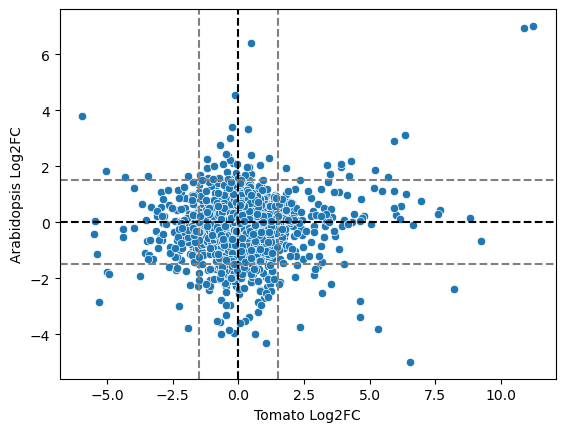

In [10]:
sns.scatterplot(data = merged_ortho_df, x ='Tomato Log2FC', y = 'Arabidopsis Log2FC' )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(x =log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(y =log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(x =log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(y =log_fc_change_evaluation_value_negative, color="grey", linestyle="--")

Text(0, 0.5, 'Orthogroup-wise log2-fold change in \n Sorghum Drought')

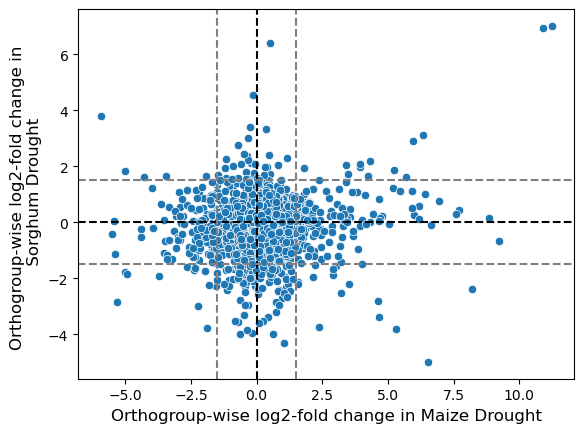

In [11]:
sns.scatterplot(x =trimmed_tomato_ortho['log2FoldChange'], y = trimmed_arabi_ortho['log2FoldChange'], )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.xlabel("Orthogroup-wise log2-fold change in Maize Drought", fontsize = 12)
plt.ylabel("Orthogroup-wise log2-fold change in \n Sorghum Drought", fontsize = 12)

In [12]:
trimmed_arabi_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
10772at3193,2411.633843,0.406150,0.237494,1.710151,0.087238,0.166693
10950at3193,2117.226134,-0.128112,0.239570,-0.534758,0.592817,0.709825
109808at3193,77.349255,0.837605,0.502047,1.668381,0.095240,0.178413
109841at3193,176.722364,0.031782,0.249482,0.127394,0.898629,0.939119
109843at3193,1008.117231,0.186384,0.239332,0.778766,0.436117,0.570527
...,...,...,...,...,...,...
9450at3193,4654.030287,0.274216,0.273276,1.003437,0.315650,0.449796
9592at3193,571.094959,0.606275,0.199227,3.043138,0.002341,0.009025
9601at3193,367.784780,-0.299745,0.184619,-1.623584,0.104465,0.190875
9609at3193,786.419667,0.008053,0.267528,0.030102,0.975986,0.983246


In [13]:
all(trimmed_arabi_ortho.index == trimmed_tomato_ortho.index)

True

In [44]:
merged_result = pd.DataFrame(data = zip(trimmed_tomato_ortho['log2FoldChange'], trimmed_arabi_ortho['log2FoldChange']), columns = ['Tomato','Arabi'])

all_over_1 = merged_result.loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)]
all_under_1 = merged_result.loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_bottom = merged_result.loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_top = merged_result.loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']>log_fc_change_evaluation_value)]

In [45]:
merged_result['Classification'] = 'Non-substantial'
merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
merged_result['Classification'].loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']>log_fc_change_evaluation_value)]= 'Substantial'

/tmp/ipykernel_1632878/2994845458.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_result['Classification'].loc[(merged_result['Tomato']>log_fc_change_evaluation_value) & (merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
/tmp/ipykernel_1632878/2994845458.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_result['Classification'].loc[(merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
/tmp/ipykernel_1632878/2994845458.py:4: SettingWithCopyWarning: 
A value is trying to be set on a cop

Text(0, 0.5, 'Orthogroup-wise log2-fold change in Sorghum Drought')

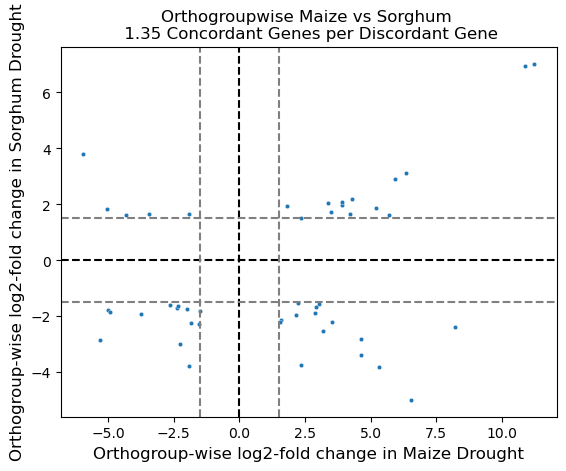

In [46]:
sns.scatterplot(data = merged_result.loc[merged_result['Classification'] == "Substantial"] , x ='Tomato', y = 'Arabi', s = 10)
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.title('Orthogroupwise Maize vs Sorghum \n 1.35 Concordant Genes per Discordant Gene')
plt.xlabel("Orthogroup-wise log2-fold change in Maize Drought", fontsize = 12)
plt.ylabel("Orthogroup-wise log2-fold change in Sorghum Drought", fontsize = 12)

In [17]:
discord_ratio = (len(all_over_1)+len(all_under_1))/(len(discord_bottom)+len(discord_top))
discord_ratio

1.35

In [18]:
discord_bottom

,Tomato,Arabi
114,2.357759,-3.743047
209,8.207177,-2.395216
306,3.038924,-1.542232
359,6.527644,-4.985649
532,1.593699,-2.137133
562,2.227724,-1.522492
658,5.326757,-3.800033
760,3.199556,-2.524036
1089,1.562471,-2.214749
1461,2.895709,-1.871239


In [19]:
discord_top

,Tomato,Arabi
382,-5.936962,3.789913
899,-5.024448,1.834759
1224,-4.304750,1.606085
1643,-3.435498,1.649623
2263,-1.924647,1.668700


In [20]:
merged_result = pd.DataFrame(data = zip(trimmed_tomato_ortho['log2FoldChange'], trimmed_arabi_ortho['log2FoldChange']), columns = ['Tomato','Arabi'])
pos_thresh = 1
neg_thresh = 1
tomato_any_change = merged_result.loc[(merged_result['Tomato']>pos_thresh)|(merged_result['Tomato']<neg_thresh)]
tomato_concordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']>pos_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']<neg_thresh))]
tomato_disconcordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']<neg_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']>pos_thresh))]
percent_concordant_tomato = len(tomato_concordant_change)/len(tomato_any_change)
percent_non_discord_tomato = len(tomato_concordant_change)/(len(tomato_concordant_change+tomato_disconcordant_change))
print(percent_concordant_tomato)
print(percent_non_discord_tomato)


arabi_any_change = merged_result.loc[(merged_result['Arabi']>pos_thresh)|(merged_result['Arabi']<neg_thresh)]
arabi_concordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']>pos_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']<neg_thresh))]
arabi_disconcordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']<neg_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']>pos_thresh))]

percent_concordant_arabi = len(arabi_concordant_change)/len(arabi_any_change)
percent_non_discord_arabi = len(arabi_concordant_change)/(len(arabi_concordant_change+arabi_disconcordant_change))

print(percent_concordant_arabi)
print(percent_non_discord_arabi)

0.8368421052631579
0.8368421052631579
0.8368421052631579
0.8368421052631579


In [21]:
arabi_disconcordant_change

,Tomato,Arabi
1,1.736015,-0.128112
5,0.314620,1.157193
15,-0.313661,2.271461
19,1.440056,-0.622317
20,2.331486,-0.012715
...,...,...
2424,1.292795,-1.086135
2428,0.334231,1.994878
2431,1.907518,0.088941
2434,2.907383,-1.671431


In [22]:
tomato_any_change

,Tomato,Arabi
0,-0.851444,0.406150
1,1.736015,-0.128112
2,-1.872667,0.837605
3,-0.736159,0.031782
4,-0.580805,0.186384
...,...,...
2465,0.156480,0.274216
2466,0.075255,0.606275
2467,-0.081129,-0.299745
2468,0.959002,0.008053


In [23]:
tomato_concordant_change

,Tomato,Arabi
0,-0.851444,0.406150
2,-1.872667,0.837605
3,-0.736159,0.031782
4,-0.580805,0.186384
6,-0.063530,0.548168
...,...,...
2465,0.156480,0.274216
2466,0.075255,0.606275
2467,-0.081129,-0.299745
2468,0.959002,0.008053


In [25]:
arabidopsis_tomato_nm = pd.read_csv('/vault/transfer/passala/OrthoDB_data/V_11_pairwise_maps_fixed_problem_species/maize_to_arabidopsis_ortholog_NM.csv')

In [26]:
arabidopsis_tomato_nm

,maize OrthoGene,arabidopsis OrthoGene,Orthogroup,maize Symbol,arabidopsis Symbol
0,4577_0:002a40,3702_0:006584,10009at3193,LOC103650270,AT5G42200
1,4577_0:0002f4,3702_0:001f5f,10092at3193,Zm00001d027886,AT2G26300
2,4577_0:000228,3702_0:000e32,10147at3193,LOC100279759,AT1G73910
3,4577_0:000228,3702_0:0018a2,10147at3193,LOC100279759,AT1G18450
4,4577_0:002ca2,3702_0:000573,10228at3193,LOC100273771,AT1G49040
...,...,...,...,...,...
51947,4577_0:0012b0,3702_0:005540,9942at3193,Zm00001d029596,AT5G09550
51948,4577_0:0023a8,3702_0:005540,9942at3193,Zm00001d005498,AT5G09550
51949,4577_0:00532e,3702_0:005540,9942at3193,Zm00001d038200,AT5G09550
51950,4577_0:006d08,3702_0:005540,9942at3193,LOC100284832,AT5G09550


In [27]:
arabidopsis_tomato_nm = arabidopsis_tomato_nm.drop_duplicates(subset = 'arabidopsis Symbol',)
arabidopsis_tomato_nm = arabidopsis_tomato_nm.drop_duplicates(subset = 'maize Symbol',)
arabidopsis_tomato_nm

,maize OrthoGene,arabidopsis OrthoGene,Orthogroup,maize Symbol,arabidopsis Symbol
0,4577_0:002a40,3702_0:006584,10009at3193,LOC103650270,AT5G42200
1,4577_0:0002f4,3702_0:001f5f,10092at3193,Zm00001d027886,AT2G26300
2,4577_0:000228,3702_0:000e32,10147at3193,LOC100279759,AT1G73910
4,4577_0:002ca2,3702_0:000573,10228at3193,LOC100273771,AT1G49040
5,4577_0:004553,3702_0:0012bf,10238at3193,LOC103627284,AT1G79120
...,...,...,...,...,...
51930,4577_0:00046a,3702_0:00121f,9828at3193,LOC100272697,AT1G74750
51932,4577_0:007379,3702_0:0052b3,9836at3193,Zm00001d045383,AT5G11380
51933,4577_0:0047e0,3702_0:001def,9877at3193,LOC100275174,AT2G42790
51936,4577_0:004f8e,3702_0:00114d,9919at3193,Zm00001d038807,AT1G15440


In [28]:
arabi_genes_trimmed = arabi_genes.merge(how = 'inner', left_index= True, right = arabidopsis_tomato_nm[['maize Symbol','arabidopsis Symbol']], right_on= 'arabidopsis Symbol')
arabi_genes_trimmed = arabi_genes_trimmed.drop_duplicates(subset = 'arabidopsis Symbol', keep = False)
arabi_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,maize Symbol,arabidopsis Symbol
38021,279.396501,0.829770,0.279637,2.967315,3.004133e-03,1.130115e-02,LOC100277009,AT1G01020
37374,1560.891356,-0.150400,0.209226,-0.718841,4.722388e-01,6.123648e-01,LOC100381417,AT1G01040
43666,459.968316,-4.223425,0.429055,-9.843555,7.308207e-23,9.550299e-21,Zm00001d049543,AT1G01060
31916,582.916252,-0.503319,0.300694,-1.673856,9.415888e-02,1.844520e-01,Zm00001d035092,AT1G01080
36300,1186.453103,-1.414880,0.296349,-4.774371,1.802694e-06,1.950987e-05,Zm00001d004473,AT1G01090
...,...,...,...,...,...,...,...,...
17525,1544.917312,0.097392,0.256502,0.379692,7.041741e-01,8.035375e-01,LOC100278439,AT5G67370
34232,185.116966,-0.513193,0.321379,-1.596844,1.103005e-01,2.080880e-01,Zm00001d034126,AT5G67390
18724,575.977171,0.409068,0.213675,1.914439,5.556413e-02,1.219793e-01,Zm00001d045296,AT5G67490
38416,526.096191,0.062253,0.182887,0.340391,7.335620e-01,8.250629e-01,Zm00001d028109,AT5G67530


In [29]:
tomato_genes_trimmed = tomato_genes.merge(how = 'inner', left_index= True, right = arabidopsis_tomato_nm[['maize Symbol','arabidopsis Symbol']], right_on= 'maize Symbol')
tomato_genes_trimmed = tomato_genes_trimmed.drop_duplicates(subset = 'arabidopsis Symbol', keep = False)
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,maize Symbol,arabidopsis Symbol
16911,1473.507174,0.325284,0.147589,2.203988,2.752522e-02,4.539811e-02,Zm00001d000060,AT1G59960
50049,388.139697,-0.124086,0.252856,-0.490738,6.236114e-01,6.903951e-01,Zm00001d000070,AT1G58320
25359,3692.220173,0.703898,0.079883,8.811633,1.233363e-18,1.042069e-17,Zm00001d000300,AT1G77840
48783,651.251808,0.888079,0.140283,6.330623,2.441727e-10,1.151319e-09,Zm00001d000305,AT3G44190
47908,369.385406,-0.001958,0.133801,-0.014631,9.883268e-01,9.910196e-01,Zm00001d000240,AT1G75510
...,...,...,...,...,...,...,...,...
40969,2178.176450,0.488594,0.102045,4.788043,1.684153e-06,5.368867e-06,Zm00001d048531,AT3G06980
3322,2734.570301,0.643375,0.134961,4.767105,1.868918e-06,5.928407e-06,Zm00001d048545,AT5G61450
35468,413.067322,-0.330452,0.131436,-2.514169,1.193132e-02,2.130159e-02,Zm00001d048551,AT2G45010
37550,253.601098,0.025617,0.152864,0.167578,8.669153e-01,8.961771e-01,Zm00001d048556,AT4G17070


In [30]:
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,maize Symbol,arabidopsis Symbol
16911,1473.507174,0.325284,0.147589,2.203988,2.752522e-02,4.539811e-02,Zm00001d000060,AT1G59960
50049,388.139697,-0.124086,0.252856,-0.490738,6.236114e-01,6.903951e-01,Zm00001d000070,AT1G58320
25359,3692.220173,0.703898,0.079883,8.811633,1.233363e-18,1.042069e-17,Zm00001d000300,AT1G77840
48783,651.251808,0.888079,0.140283,6.330623,2.441727e-10,1.151319e-09,Zm00001d000305,AT3G44190
47908,369.385406,-0.001958,0.133801,-0.014631,9.883268e-01,9.910196e-01,Zm00001d000240,AT1G75510
...,...,...,...,...,...,...,...,...
40969,2178.176450,0.488594,0.102045,4.788043,1.684153e-06,5.368867e-06,Zm00001d048531,AT3G06980
3322,2734.570301,0.643375,0.134961,4.767105,1.868918e-06,5.928407e-06,Zm00001d048545,AT5G61450
35468,413.067322,-0.330452,0.131436,-2.514169,1.193132e-02,2.130159e-02,Zm00001d048551,AT2G45010
37550,253.601098,0.025617,0.152864,0.167578,8.669153e-01,8.961771e-01,Zm00001d048556,AT4G17070


In [31]:
arabi_genes_trimmed = arabi_genes_trimmed.loc[arabi_genes_trimmed['arabidopsis Symbol'].isin(tomato_genes_trimmed['arabidopsis Symbol'])]
tomato_genes_trimmed = tomato_genes_trimmed.loc[tomato_genes_trimmed['maize Symbol'].isin(arabi_genes_trimmed['maize Symbol'])]


In [32]:
tomato_genes_trimmed

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,maize Symbol,arabidopsis Symbol
16911,1473.507174,0.325284,0.147589,2.203988,2.752522e-02,4.539811e-02,Zm00001d000060,AT1G59960
25359,3692.220173,0.703898,0.079883,8.811633,1.233363e-18,1.042069e-17,Zm00001d000300,AT1G77840
48783,651.251808,0.888079,0.140283,6.330623,2.441727e-10,1.151319e-09,Zm00001d000305,AT3G44190
47908,369.385406,-0.001958,0.133801,-0.014631,9.883268e-01,9.910196e-01,Zm00001d000240,AT1G75510
15453,60.769565,-1.459794,0.234846,-6.215959,5.101216e-10,2.339951e-09,Zm00001d000241,AT4G11060
...,...,...,...,...,...,...,...,...
40969,2178.176450,0.488594,0.102045,4.788043,1.684153e-06,5.368867e-06,Zm00001d048531,AT3G06980
3322,2734.570301,0.643375,0.134961,4.767105,1.868918e-06,5.928407e-06,Zm00001d048545,AT5G61450
35468,413.067322,-0.330452,0.131436,-2.514169,1.193132e-02,2.130159e-02,Zm00001d048551,AT2G45010
37550,253.601098,0.025617,0.152864,0.167578,8.669153e-01,8.961771e-01,Zm00001d048556,AT4G17070


In [33]:
tomato_genes_trimmed = (tomato_genes_trimmed.set_index('arabidopsis Symbol')
          .reindex(arabi_genes_trimmed.set_index('arabidopsis Symbol').index)
          .reset_index()
       )

In [34]:
tomato_genes_trimmed

,arabidopsis Symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,maize Symbol
0,AT1G01060,34929.523143,0.440635,0.239069,1.843127,6.531051e-02,9.844417e-02,Zm00001d049543
1,AT1G01080,843.563459,0.444789,0.159040,2.796717,5.162469e-03,9.866531e-03,Zm00001d035092
2,AT1G01090,3520.895636,0.175343,0.097188,1.804174,7.120399e-02,1.063158e-01,Zm00001d004473
3,AT1G01100,1253.521617,-0.824984,0.137779,-5.987740,2.127773e-09,9.198224e-09,Zm00001d049674
4,AT1G01110,63.460408,-2.507536,0.313384,-8.001480,1.229326e-15,8.694748e-15,Zm00001d049684
...,...,...,...,...,...,...,...,...
4685,AT5G67320,334.679382,-0.425255,0.128288,-3.314853,9.169149e-04,1.992626e-03,Zm00001d004383
4686,AT5G67390,25.293889,-4.653537,0.701166,-6.636857,3.204432e-11,1.627518e-10,Zm00001d034126
4687,AT5G67490,254.363760,0.125846,0.146900,0.856679,3.916221e-01,4.688772e-01,Zm00001d045296
4688,AT5G67530,390.100932,-0.225925,0.177439,-1.273250,2.029294e-01,2.673295e-01,Zm00001d028109


In [35]:
arabi_genes_trimmed = arabi_genes_trimmed.reset_index()

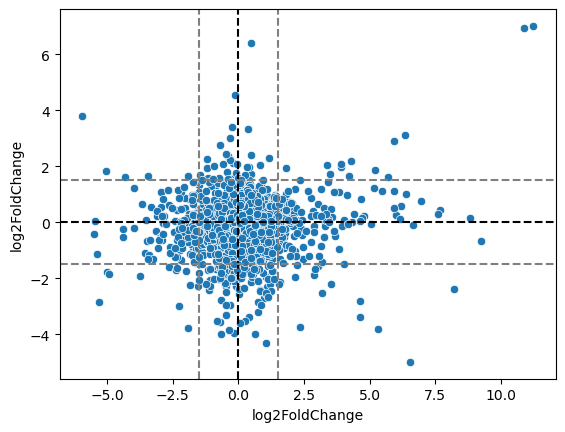

In [36]:
sns.scatterplot(x =trimmed_tomato_ortho['log2FoldChange'], y = trimmed_arabi_ortho['log2FoldChange'], )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")

Text(0, 0.5, 'Genewise log2-fold change in \n Sorghum Drought')

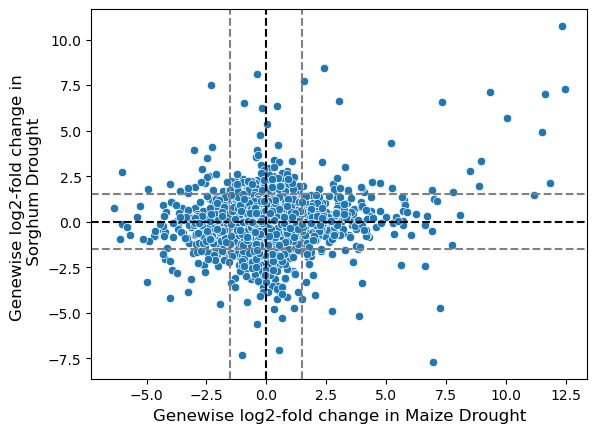

In [37]:
sns.scatterplot(x =tomato_genes_trimmed['log2FoldChange'], y = arabi_genes_trimmed['log2FoldChange'])
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.xlabel("Genewise log2-fold change in Maize Drought", fontsize = 12)
plt.ylabel("Genewise log2-fold change in \n Sorghum Drought", fontsize = 12)

In [38]:
new_merged_result = pd.DataFrame(data = zip(tomato_genes_trimmed['log2FoldChange'], arabi_genes_trimmed['log2FoldChange']), columns = ['Tomato','Arabi'])

all_over_1 = new_merged_result.loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]
all_under_1 = new_merged_result.loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_bottom = new_merged_result.loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]
discord_top = new_merged_result.loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]

In [39]:
new_merged_result['Classification'] = 'Non-substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
new_merged_result['Classification'].loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)]= 'Substantial'

/tmp/ipykernel_1632878/1856289886.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_merged_result['Classification'].loc[(new_merged_result['Tomato']>log_fc_change_evaluation_value) & (new_merged_result['Arabi']>log_fc_change_evaluation_value)] = 'Substantial'
/tmp/ipykernel_1632878/1856289886.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_merged_result['Classification'].loc[(new_merged_result['Tomato']<log_fc_change_evaluation_value_negative) & (new_merged_result['Arabi']<log_fc_change_evaluation_value_negative)]= 'Substantial'
/tmp/ipykernel_1632878/1856289886.py:4: SettingWithCopyWarning: 
A value is t

Text(0, 0.5, 'Genewise log2-fold change in Sorghum Drought')

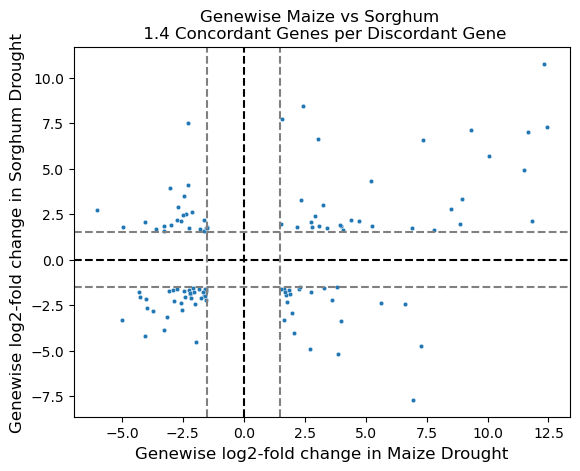

In [42]:
sns.scatterplot(data = new_merged_result.loc[new_merged_result['Classification'] == "Substantial"] , x ='Tomato', y = 'Arabi', s = 10 )
plt.axvline(0, color="k", linestyle="--")
plt.axhline(0, color="k", linestyle="--")
plt.axvline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value, color="grey", linestyle="--")
plt.axvline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.axhline(log_fc_change_evaluation_value_negative, color="grey", linestyle="--")
plt.title('Genewise Maize vs Sorghum \n 1.4 Concordant Genes per Discordant Gene')
plt.xlabel("Genewise log2-fold change in Maize Drought", fontsize = 12)
plt.ylabel("Genewise log2-fold change in Sorghum Drought", fontsize = 12)

In [41]:
discord_ratio = (len(all_over_1)+len(all_under_1))/(len(discord_bottom)+len(discord_top))
discord_ratio

1.4042553191489362

In [342]:
all_over_1

,Tomato,Arabi
128,5.420722,2.289623
163,2.688214,1.658393
165,1.529409,1.995355
351,6.788676,2.372646
582,7.428141,2.349108
660,4.131078,2.303250
847,4.748212,2.510446
968,5.096113,2.105806
1064,3.039029,1.728921
1218,2.317202,3.015622


In [343]:
all_under_1

,Tomato,Arabi
1302,-1.546548,-1.996698
3401,-1.570759,-1.713524
4504,-1.584948,-4.405051
4944,-5.482556,-1.861803
5162,-1.628072,-2.431291


In [344]:
merged_result

,Tomato,Arabi
0,-0.145039,0.054831
1,-0.023699,-0.092506
2,0.074602,-0.769619
3,-0.647447,-0.563822
4,-0.407818,-0.445230
...,...,...
3199,2.262803,0.036704
3200,0.376672,0.168016
3201,0.401132,0.728854
3202,-0.146726,-0.288193


In [345]:
merged_result = pd.DataFrame(data = zip(tomato_genes_trimmed['log2FoldChange'], arabi_genes_trimmed['log2FoldChange']), columns = ['Tomato','Arabi'])

pos_thresh = 0
neg_thresh = 0
tomato_any_change = merged_result.loc[(merged_result['Tomato']>pos_thresh)|(merged_result['Tomato']<neg_thresh)]
tomato_concordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']>pos_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']<neg_thresh))]
tomato_disconcordant_change = merged_result.loc[((merged_result['Tomato']>pos_thresh) & (merged_result['Arabi']<neg_thresh)) | ((merged_result['Tomato']<neg_thresh) & (merged_result['Arabi']>pos_thresh))]
percent_concordant_tomato = len(tomato_concordant_change)/len(tomato_any_change)
percent_non_discord_tomato = len(tomato_concordant_change)/(len(tomato_concordant_change+tomato_disconcordant_change))
print(percent_concordant_tomato)
print(percent_non_discord_tomato)


arabi_any_change = merged_result.loc[(merged_result['Arabi']>pos_thresh)|(merged_result['Arabi']<neg_thresh)]
arabi_concordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']>pos_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']<neg_thresh))]
arabi_disconcordant_change = merged_result.loc[((merged_result['Arabi']>pos_thresh) & (merged_result['Tomato']<neg_thresh)) | ((merged_result['Arabi']<neg_thresh) & (merged_result['Tomato']>pos_thresh))]

percent_concordant_arabi = len(arabi_concordant_change)/len(arabi_any_change)
percent_non_discord_arabi = len(arabi_concordant_change)/(len(arabi_concordant_change+arabi_disconcordant_change))

print(percent_concordant_arabi)
print(percent_non_discord_arabi)

0.6387687188019967
0.6387687188019967
0.6387687188019967
0.6387687188019967


In [346]:
stats.spearmanr(a=tomato_genes_trimmed['log2FoldChange'], b = arabi_genes_trimmed['log2FoldChange'] )

SignificanceResult(statistic=0.3778838983240342, pvalue=2.6260518647079396e-203)

In [347]:
down = tomato_genes_trimmed[
    (tomato_genes_trimmed["log2FoldChange"] <= -2) & (tomato_genes_trimmed["padj"] <= 0.001)
]
up = tomato_genes_trimmed[
    (tomato_genes_trimmed["log2FoldChange"] >= 2) & (tomato_genes_trimmed["padj"] <= 0.001)
]
down_arabi = arabi_genes_trimmed[
    (arabi_genes_trimmed["log2FoldChange"] <= -2)
    & (arabi_genes_trimmed["padj"] <= 0.001)
]
up_arabi = arabi_genes_trimmed[
    (arabi_genes_trimmed["log2FoldChange"] >= 2) & (arabi_genes_trimmed["padj"] <= 0.001)
]

In [348]:
down_arabi_ortho = trimmed_arabi_ortho[
    (trimmed_arabi_ortho["log2FoldChange"] <= -2)
    & (trimmed_arabi_ortho["padj"] <= 0.001)
]
up_arabi_ortho = trimmed_arabi_ortho[
    (trimmed_arabi_ortho["log2FoldChange"] >= 2) & (trimmed_arabi_ortho["padj"] <= 0.001)]

down_ortho = trimmed_tomato_ortho[
    (trimmed_tomato_ortho["log2FoldChange"] <= -2) & (trimmed_tomato_ortho["padj"] <= 0.001)
]
up_ortho = trimmed_tomato_ortho[
    (trimmed_tomato_ortho["log2FoldChange"] >= 2) & (trimmed_tomato_ortho["padj"] <= 0.001)
]

In [349]:
len(up_arabi_ortho.merge(how = "inner", right_index = True, left_index= True, right = up_ortho))

5

In [350]:
up_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
114446at3193,1241.209942,3.515908,0.459146,7.657494,1.895955e-14,3.277839e-13
118011at3193,572.664338,2.646269,0.254130,10.413035,2.162169e-25,1.102920e-23
118239at3193,218.445035,2.275324,0.171891,13.236980,5.366364e-40,6.143890e-38
118532at3193,1725.105212,2.161990,0.139590,15.488117,4.173376e-54,1.023868e-51
127999at3193,39.111363,2.056699,0.405571,5.071118,3.954849e-07,2.217125e-06
136845at3193,242.212243,2.145751,0.298576,7.186620,6.641495e-13,9.452205e-12
137296at3193,707.220252,2.480940,0.193344,12.831742,1.088883e-37,1.121985e-35
138520at3193,44.488378,4.133091,0.588411,7.024155,2.153657e-12,2.760110e-11
139009at3193,99.410629,2.081851,0.330890,6.291672,3.140650e-10,2.958068e-09
139101at3193,78.287068,2.997948,0.494597,6.061394,1.349466e-09,1.164564e-08


In [351]:
up_arabi_ortho

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
137296at3193,2161.067885,2.174250,0.528502,4.113983,3.888909e-05,5.491535e-04
138520at3193,76.412410,2.153709,0.393055,5.479408,4.267515e-08,1.911330e-06
402643at3193,166.541104,2.019380,0.352363,5.730967,9.985962e-09,5.466390e-07
404029at3193,194.154600,2.164346,0.350151,6.181175,6.362634e-10,5.037842e-08
649605at3193,47.270308,2.015115,0.408406,4.934102,8.052030e-07,2.190350e-05
685441at3193,81.660743,2.091774,0.416022,5.028042,4.955136e-07,1.445465e-05


In [352]:
up

,sorghum Symbol,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,maize Symbol
100,LOC8079693,195.258840,2.983458,0.416281,7.166938,7.669375e-13,1.113223e-11,Zm00001d034723
128,LOC8057046,2520.801630,5.420722,0.532738,10.175209,2.558510e-24,1.155618e-22,Zm00001d034643
163,LOC8057096,41.640932,2.688214,0.455019,5.907911,3.464740e-09,3.055697e-08,Zm00001d034571
304,LOC8060482,183.413908,3.368102,0.296143,11.373238,5.683920e-30,3.862100e-28,Zm00001d033990
319,LOC110436814,41370.139495,2.435272,0.166060,14.664978,1.080524e-48,2.059321e-46,Zm00001d033931
...,...,...,...,...,...,...,...,...
5726,LOC8070713,1006.526721,2.215971,0.333194,6.650688,2.917258e-11,3.443422e-10,Zm00001d045392
5747,LOC8071335,1115.939142,2.910148,0.192626,15.107733,1.440095e-51,3.246030e-49,Zm00001d045311
5759,LOC8076148,63.523609,2.440673,0.484010,5.042613,4.592178e-07,2.807768e-06,Zm00001d045204
5776,LOC8065428,25.333567,3.370250,0.568750,5.925710,3.109504e-09,2.760053e-08,Zm00001d037080


In [353]:
up_arabi

,index,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,maize Symbol,sorghum Symbol
128,9124,3100.928023,2.289623,0.461379,4.962561,6.956980e-07,2.118509e-05,Zm00001d034643,LOC8057046
964,5026,2995.168619,2.039980,0.150657,13.540539,9.012488e-42,1.756444e-37,Zm00001d032293,LOC8080108
968,48187,94.957402,2.105806,0.487992,4.315252,1.594213e-05,2.832235e-04,Zm00001d029349,LOC8080751
1271,14949,497.115989,3.143004,0.753548,4.170939,3.033474e-05,4.760014e-04,Zm00001d028408,LOC8054347
1842,38483,198.980996,2.434358,0.367586,6.622557,3.530374e-11,4.169907e-09,Zm00001d005283,LOC8062599
2523,10803,4971.656556,2.025416,0.276492,7.325419,2.381541e-13,4.945837e-11,Zm00001d039315,LOC8081371
2591,13898,4238.575944,2.140743,0.519352,4.121947,3.756841e-05,5.671346e-04,Zm00001d039566,LOC8078754
2609,37520,47.242209,2.009489,0.416134,4.828946,1.372575e-06,3.794341e-05,Zm00001d039634,LOC8078789
2665,32132,972.246781,3.103060,0.639684,4.850928,1.228853e-06,3.460856e-05,Zm00001d039942,LOC8061349
2977,68022,552.870627,2.066635,0.272540,7.582869,3.379950e-14,9.541208e-12,Zm00001d044124,LOC8058201


In [354]:
up_arabi.merge(how = "inner", on = 'arabidopsis Symbol', right = up)

KeyError: 'arabidopsis Symbol'